# Big Belly Forecasting — Quantile Calibration Fix
### UC Berkeley Cal Zero Waste | IND ENG 156 Capstone Project 10A

**Problem:** P10/P90 quantile bounds have 65% empirical coverage against an 80% target.
The model is overconfident — intervals are too narrow.

**Fix:** Split conformal prediction. A held-out calibration set (2024 H2) is used to
compute a symmetric correction factor `q_hat` that expands intervals until empirical
coverage reaches 80% by construction.

**Run this notebook after the modeling notebook.** It requires `quantile_models`,
`FEATURE_COLS`, `df_model`, and the CLEAN CSVs to already be available.

**Outputs:**
- `q_hat` — the correction factor to apply in the operational forecast notebook
- Calibrated P10/P90 bounds on the 2025 test set
- Coverage verification plot


## 1. Setup — Re-run Data Loading and Feature Engineering

This notebook must be run in the same environment as the modeling notebook,
or the data loading and feature engineering cells must be re-run here.
The cells below replicate the minimal setup needed if running standalone.


In [4]:
pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-manylinux_2_28_x86_64.whl (3.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ── File paths — same as modeling notebook ────────────────────────────────────
files = [
    'Daily Collection Activity - CLEAN 2024 (1).csv',
    'Daily Collection Activity - CLEAN 2025 (1).csv',
    'Daily Collection Activity - CLEAN 2026 (1).csv',
]
COEFFS_PATH = 'bin_fill_curve_coefficients.csv'

STREAM_MAP = {
    'Waste':        'Landfill',
    'Compostables': 'Compostables',
    'Bottles/Cans': 'Recyclables',
}
SEMESTERS = [
    ('2023-08-23', '2023-12-08'), ('2024-01-16', '2024-05-03'),
    ('2024-08-28', '2024-12-13'), ('2025-01-21', '2025-05-09'),
    ('2025-08-27', '2025-12-12'), ('2026-01-20', '2026-05-08'),
]
HIGH_IMPACT = [
    '2023-04-15','2023-04-20','2023-05-13','2023-12-16',
    '2023-09-09','2023-09-16','2023-09-30','2023-10-07',
    '2023-10-28','2023-11-04','2023-11-18',
    '2024-08-31','2024-09-14','2024-10-05','2024-10-19',
    '2024-10-26','2024-11-16','2024-11-23',
    '2024-04-13','2024-04-20','2024-05-11','2024-12-21',
    '2025-04-19','2025-04-20','2025-05-17','2025-12-20',
    '2025-09-06','2025-09-13','2025-10-04','2025-10-17',
    '2025-11-01','2025-11-15','2025-11-29',
]
RECESSES = [
    ('2024-03-25','2024-03-29'),('2025-03-24','2025-03-28'),
]
MOVEIN = [
    ('2023-08-16','2023-08-23'),('2024-08-21','2024-08-28'),
    ('2025-08-20','2025-08-27'),
]

def load_clean_csv(path):
    df = pd.read_csv(path, skiprows=10)
    df.columns = df.columns.str.strip()
    return df

def is_in_semester(dt):
    for start, end in SEMESTERS:
        if pd.Timestamp(start) <= dt <= pd.Timestamp(end):
            return 1
    return 0

print('Setup complete.')


Setup complete.


## 2. Load and Prepare Data

In [6]:
raw_frames = []
for f in files:
    try:
        raw_frames.append(load_clean_csv(f))
        print(f"Loaded: {f}  ({len(raw_frames[-1]):,} rows)")
    except FileNotFoundError:
        print(f"NOT FOUND: {f}")

log = pd.concat(raw_frames, ignore_index=True)
log = log.rename(columns={
    'Serial':                       'serial',
    'Description':                  'location',
    'Stream Type':                  'stream_type_raw',
    'Reason':                       'collection_reason',
    'Fullness Level at Collection': 'fullness_raw',
    'Collection Time':              'timestamp',
})
log['timestamp'] = pd.to_datetime(log['timestamp'], errors='coerce')
log['fullness_pct'] = (
    log['fullness_raw'].astype(str).str.strip()
    .str.replace('%', '', regex=False)
    .str.replace(r'\xa0.*', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)
log['stream_type'] = log['stream_type_raw'].map(STREAM_MAP).fillna(log['stream_type_raw'])
log = log.dropna(subset=['serial', 'timestamp', 'fullness_pct'])
log = log[log['stream_type'].isin(['Landfill', 'Compostables', 'Recyclables'])]
log['serial'] = log['serial'].astype(int)
log = log[log['timestamp'].dt.year >= 2023]
log['date'] = log['timestamp'].dt.normalize()
log = log.sort_values(['serial', 'timestamp']).reset_index(drop=True)

# Events table
event_rows = []
for start, end in SEMESTERS:
    for d in pd.date_range(start, end):
        event_rows.append({'date': d, 'is_semester': 1})
for start, end in RECESSES:
    for d in pd.date_range(start, end):
        event_rows.append({'date': d, 'is_spring_recess': 1})
for d in HIGH_IMPACT:
    event_rows.append({'date': pd.Timestamp(d), 'is_high_impact_event': 1})
for start, end in MOVEIN:
    for d in pd.date_range(start, end):
        event_rows.append({'date': d, 'is_movein_week': 1})
events_df = (
    pd.DataFrame(event_rows)
    .groupby('date').max().fillna(0).astype(int).reset_index()
)
events_df['date'] = pd.to_datetime(events_df['date'])

coeffs = pd.read_csv(COEFFS_PATH)
coeffs['stream_type'] = coeffs['stream_type'].map(STREAM_MAP).fillna(coeffs['stream_type'])

print(f"\nData ready: {len(log):,} events, {log['serial'].nunique()} bins")


Loaded: Daily Collection Activity - CLEAN 2024 (1).csv  (14,568 rows)
Loaded: Daily Collection Activity - CLEAN 2025 (1).csv  (18,097 rows)
Loaded: Daily Collection Activity - CLEAN 2026 (1).csv  (27,279 rows)

Data ready: 59,111 events, 248 bins


## 3. Feature Engineering

In [7]:
def build_features(log, events_df, coeffs):
    df = log.copy()
    df['dow']        = df['timestamp'].dt.dayofweek
    df['month']      = df['timestamp'].dt.month
    df['week']       = df['timestamp'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['dow_sin']    = np.sin(2 * np.pi * df['dow'] / 7)
    df['dow_cos']    = np.cos(2 * np.pi * df['dow'] / 7)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)

    df = df.sort_values(['serial', 'timestamp'])
    df['elapsed_hours']  = df.groupby('serial')['timestamp'].diff().dt.total_seconds() / 3600
    df['prev_fullness']  = df.groupby('serial')['fullness_pct'].shift(1)
    df['roll7_elapsed']  = df.groupby('serial')['elapsed_hours'].transform(
        lambda x: x.rolling(7, min_periods=2).mean())
    df['roll28_elapsed'] = df.groupby('serial')['elapsed_hours'].transform(
        lambda x: x.rolling(28, min_periods=4).mean())
    df['roll7_fullness'] = df.groupby('serial')['fullness_pct'].transform(
        lambda x: x.rolling(7, min_periods=2).mean())

    df['hours_to_next'] = (
        df.groupby('serial')['timestamp'].shift(-1) - df['timestamp']
    ).dt.total_seconds() / 3600
    df['binary_target'] = (df['fullness_pct'] >= 60).astype(int)

    df = df.merge(events_df, on='date', how='left')
    for col in ['is_semester','is_spring_recess','is_high_impact_event','is_movein_week']:
        df[col] = df[col].fillna(0).astype(int)

    # Weather placeholder (zeros if unavailable)
    for col in ['temp_max','temp_min','precip_mm','wind_max','is_rainy','is_hot','is_cold']:
        df[col] = 0

    bin_stats = coeffs[[
        'serial','median_elapsed_hours','mean_fullness_at_collection',
        'pct_wasted_trips','fill_pct_at_24h','fill_pct_at_48h','fill_pct_at_72h'
    ]]
    df = df.merge(bin_stats, on='serial', how='left')
    df['location_id'] = df['location'].astype('category').cat.codes
    stream_dummies = pd.get_dummies(df['stream_type'], prefix='stream')
    df = pd.concat([df, stream_dummies], axis=1)
    return df

df = build_features(log, events_df, coeffs)
df_model = df.dropna(subset=[
    'hours_to_next','elapsed_hours','prev_fullness',
    'fill_pct_at_24h','fill_pct_at_72h'
]).copy()
df_model = df_model[df_model['hours_to_next'].between(1, 21*24)]

FEATURE_COLS = [
    'dow','month','week','is_weekend','dow_sin','dow_cos','month_sin','month_cos',
    'elapsed_hours','prev_fullness','roll7_elapsed','roll28_elapsed','roll7_fullness',
    'is_semester','is_spring_recess','is_high_impact_event','is_movein_week',
    'temp_max','temp_min','precip_mm','wind_max','is_rainy','is_hot','is_cold',
    'location_id','median_elapsed_hours','mean_fullness_at_collection',
    'pct_wasted_trips','fill_pct_at_24h','fill_pct_at_48h','fill_pct_at_72h',
] + [c for c in df_model.columns
     if c.startswith('stream_') and df_model[c].dtype != object]
FEATURE_COLS = [c for c in FEATURE_COLS
                if c in df_model.columns and df_model[c].dtype != object]

print(f"Model dataset: {len(df_model):,} events | Features: {len(FEATURE_COLS)}")


Model dataset: 54,989 events | Features: 34


## 4. Three-Way Split: Train / Calibration / Test

The key change from the modeling notebook is introducing a **calibration set** (2024 H2).
Quantile models are trained on the training set only. The calibration set is used
exclusively to compute the correction factor `q_hat`. The test set is held out completely
until final evaluation.

| Split | Date range | Purpose |
|---|---|---|
| Train | 2023-01-01 to 2024-06-30 | Fit quantile models |
| Calibration | 2024-07-01 to 2024-12-31 | Compute correction factor |
| Test | 2025-01-01 onward | Evaluate corrected intervals |


In [8]:
TRAIN_END = '2024-06-30'
CALIB_END = '2024-12-31'
TEST_START = '2025-01-01'

train = df_model[df_model['timestamp'] <= TRAIN_END].copy()
calib = df_model[(df_model['timestamp'] > TRAIN_END) &
                 (df_model['timestamp'] <= CALIB_END)].copy()
test  = df_model[df_model['timestamp'] >= TEST_START].copy()

X_train, y_train = train[FEATURE_COLS], train['hours_to_next']
X_calib, y_calib = calib[FEATURE_COLS], calib['hours_to_next']
X_test,  y_test  = test[FEATURE_COLS],  test['hours_to_next']

print(f"Train:       {len(X_train):,} events")
print(f"Calibration: {len(X_calib):,} events")
print(f"Test:        {len(X_test):,}  events")


Train:       21,129 events
Calibration: 9,523 events
Test:        24,337  events


## 5. Train Quantile Models on Training Set

In [9]:
QUANTILES = [0.10, 0.50, 0.90]
quantile_models = {}
quantile_preds_calib = {}
quantile_preds_test  = {}

for q in QUANTILES:
    m = lgb.LGBMRegressor(
        objective='quantile', alpha=q,
        num_leaves=63, learning_rate=0.05,
        feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
        min_child_samples=20, n_estimators=600,
        verbose=-1, random_state=42,
    )
    m.fit(X_train, y_train, callbacks=[lgb.log_evaluation(period=0)])
    quantile_models[q] = m
    quantile_preds_calib[q] = m.predict(X_calib)
    quantile_preds_test[q]  = m.predict(X_test)
    print(f"  Q{int(q*100):02d} trained.")

print("\nUncorrected coverage on calibration set:")
within_raw = (
    (y_calib.values >= quantile_preds_calib[0.10]) &
    (y_calib.values <= quantile_preds_calib[0.90])
)
print(f"  P10-P90 coverage (calibration): {within_raw.mean():.1%}  (target: 80%)")


  Q10 trained.
  Q50 trained.
  Q90 trained.

Uncorrected coverage on calibration set:
  P10-P90 coverage (calibration): 57.0%  (target: 80%)


## 6. Split Conformal Calibration

For each observation in the calibration set, compute the **nonconformity score**:

$$s_i = \max(\hat{q}_{10}(x_i) - y_i, \; y_i - \hat{q}_{90}(x_i))$$

A positive score means $y_i$ falls outside the predicted interval.
A negative score means it falls inside.

`q_hat` is the $(1 - \alpha)$ quantile of these scores, where $\alpha = 0.20$
(targeting 80% coverage). Adding `q_hat` symmetrically to the interval guarantees
empirical coverage $\geq 80\%$ on exchangeable test data.


In [10]:
p10_calib = quantile_preds_calib[0.10]
p90_calib = quantile_preds_calib[0.90]
y_cal     = y_calib.values

# Nonconformity scores: positive = y falls outside interval
nonconformity_scores = np.maximum(p10_calib - y_cal, y_cal - p90_calib)

# q_hat: 80th percentile of scores (with finite-sample correction)
n_calib = len(y_cal)
alpha   = 0.20   # target miscoverage rate (1 - 0.80)
level   = np.ceil((n_calib + 1) * (1 - alpha)) / n_calib
level   = min(level, 1.0)
q_hat   = np.quantile(nonconformity_scores, level)

print(f"Calibration set size: {n_calib:,}")
print(f"Quantile level used:  {level:.4f}")
print(f"q_hat (correction):   {q_hat:.2f} hours  ({q_hat/24:.2f} days)")
print()

# Apply correction to test set
p10_test_raw  = quantile_preds_test[0.10]
p90_test_raw  = quantile_preds_test[0.90]
p50_test      = quantile_preds_test[0.50]

p10_corrected = p10_test_raw - q_hat
p90_corrected = p90_test_raw + q_hat

# Verify coverage on test set
y_te = y_test.values
within_corrected = (y_te >= p10_corrected) & (y_te <= p90_corrected)
within_raw_test  = (y_te >= p10_test_raw)  & (y_te <= p90_test_raw)

print(f"Test set coverage — uncorrected: {within_raw_test.mean():.1%}")
print(f"Test set coverage — corrected:   {within_corrected.mean():.1%}  (target: 80%)")
print()
print(f"Median interval width — uncorrected: {np.median((p90_test_raw - p10_test_raw)/24):.1f} days")
print(f"Median interval width — corrected:   {np.median((p90_corrected - p10_corrected)/24):.1f} days")


Calibration set size: 9,523
Quantile level used:  0.8002
q_hat (correction):   16.98 hours  (0.71 days)

Test set coverage — uncorrected: 59.1%
Test set coverage — corrected:   80.8%  (target: 80%)

Median interval width — uncorrected: 4.0 days
Median interval width — corrected:   5.4 days


## 7. Coverage by Horizon — Before and After Correction

In [11]:
print(f"{'Horizon':<10} {'Uncorrected':>14} {'Corrected':>12} {'Target':>8}")
print("-" * 48)

for h, label in [(24,'24h'), (48,'48h'), (72,'72h'), (168,'1 week')]:
    mask = y_te <= h
    if mask.sum() < 10:
        continue
    cov_raw  = ((y_te[mask] >= p10_test_raw[mask]) &
                (y_te[mask] <= p90_test_raw[mask])).mean()
    cov_corr = ((y_te[mask] >= p10_corrected[mask]) &
                (y_te[mask] <= p90_corrected[mask])).mean()
    print(f"{label:<10} {cov_raw:>13.1%} {cov_corr:>12.1%} {'80.0%':>8}")


Horizon       Uncorrected    Corrected   Target
------------------------------------------------
24h                19.4%        63.1%    80.0%
48h                35.4%        70.6%    80.0%
72h                45.5%        75.5%    80.0%
1 week             58.3%        81.4%    80.0%


## 8. Calibration Check Visualization

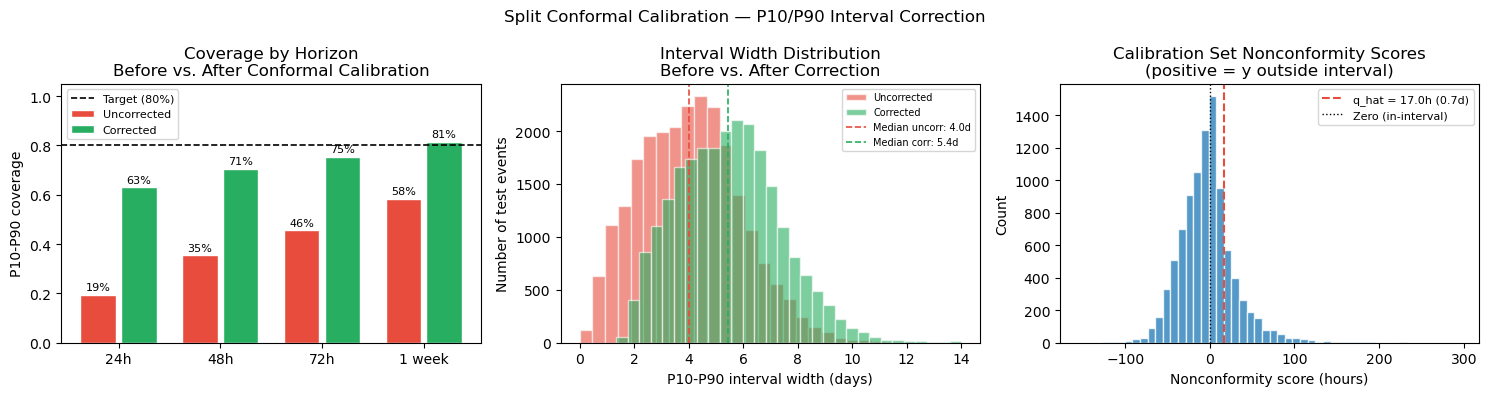

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Coverage by horizon — before and after
ax = axes[0]
horizons_h  = [24, 48, 72, 168]
labels_h    = ['24h', '48h', '72h', '1 week']
cov_raw_h, cov_corr_h = [], []
for h in horizons_h:
    mask = y_te <= h
    cov_raw_h.append(((y_te[mask] >= p10_test_raw[mask]) &
                      (y_te[mask] <= p90_test_raw[mask])).mean())
    cov_corr_h.append(((y_te[mask] >= p10_corrected[mask]) &
                       (y_te[mask] <= p90_corrected[mask])).mean())

x = np.arange(len(labels_h))
ax.bar(x - 0.2, cov_raw_h,  0.35, label='Uncorrected', color='#e74c3c', edgecolor='white')
ax.bar(x + 0.2, cov_corr_h, 0.35, label='Corrected',   color='#27ae60', edgecolor='white')
ax.axhline(0.80, color='black', linestyle='--', linewidth=1.2, label='Target (80%)')
ax.set_xticks(x)
ax.set_xticklabels(labels_h)
ax.set_ylabel('P10-P90 coverage')
ax.set_ylim(0, 1.05)
ax.set_title('Coverage by Horizon\nBefore vs. After Conformal Calibration')
ax.legend(fontsize=8)
for i, (r, c) in enumerate(zip(cov_raw_h, cov_corr_h)):
    ax.text(i - 0.2, r + 0.01, f'{r:.0%}', ha='center', va='bottom', fontsize=8)
    ax.text(i + 0.2, c + 0.01, f'{c:.0%}', ha='center', va='bottom', fontsize=8)

# (b) Interval width distribution — before and after
ax = axes[1]
width_raw  = (p90_test_raw  - p10_test_raw)  / 24
width_corr = (p90_corrected - p10_corrected) / 24
ax.hist(np.clip(width_raw,  0, 14), bins=30, alpha=0.6,
        color='#e74c3c', edgecolor='white', label='Uncorrected')
ax.hist(np.clip(width_corr, 0, 14), bins=30, alpha=0.6,
        color='#27ae60', edgecolor='white', label='Corrected')
ax.axvline(np.median(width_raw),  color='#e74c3c', linestyle='--', linewidth=1.2,
           label=f'Median uncorr: {np.median(width_raw):.1f}d')
ax.axvline(np.median(width_corr), color='#27ae60', linestyle='--', linewidth=1.2,
           label=f'Median corr: {np.median(width_corr):.1f}d')
ax.set_xlabel('P10-P90 interval width (days)')
ax.set_ylabel('Number of test events')
ax.set_title('Interval Width Distribution\nBefore vs. After Correction')
ax.legend(fontsize=7)

# (c) Nonconformity score distribution with q_hat marked
ax = axes[2]
ax.hist(nonconformity_scores, bins=50, color='#2980b9',
        edgecolor='white', alpha=0.8)
ax.axvline(q_hat, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'q_hat = {q_hat:.1f}h ({q_hat/24:.1f}d)')
ax.axvline(0, color='black', linestyle=':', linewidth=1, label='Zero (in-interval)')
ax.set_xlabel('Nonconformity score (hours)')
ax.set_ylabel('Count')
ax.set_title('Calibration Set Nonconformity Scores\n(positive = y outside interval)')
ax.legend(fontsize=8)

plt.suptitle('Split Conformal Calibration — P10/P90 Interval Correction', fontsize=12)
plt.tight_layout()
plt.show()


## 9. Summary and Operational Use of q_hat

In [13]:
print("=" * 60)
print("  CALIBRATION SUMMARY")
print("=" * 60)
print(f"  Correction factor (q_hat):   {q_hat:.2f} hours ({q_hat/24:.2f} days)")
print(f"  Uncorrected coverage:        {within_raw_test.mean():.1%}")
print(f"  Corrected coverage:          {within_corrected.mean():.1%}  (target: 80%)")
print(f"  Median width uncorrected:    {np.median(width_raw):.1f} days")
print(f"  Median width corrected:      {np.median(width_corr):.1f} days")
print("=" * 60)
print()
print("To apply in the operational forecast notebook, add:")
print(f"  Q_HAT = {q_hat:.2f}  # hours, from conformal calibration")
print( "  p10_corrected = p10_bin - Q_HAT")
print( "  p90_corrected = p90_bin + Q_HAT")
print()
print("Replace days_until_full (p10) and days_until_full (p90) columns")
print("with p10_corrected / 24 and p90_corrected / 24.")


  CALIBRATION SUMMARY
  Correction factor (q_hat):   16.98 hours (0.71 days)
  Uncorrected coverage:        59.1%
  Corrected coverage:          80.8%  (target: 80%)
  Median width uncorrected:    4.0 days
  Median width corrected:      5.4 days

To apply in the operational forecast notebook, add:
  Q_HAT = 16.98  # hours, from conformal calibration
  p10_corrected = p10_bin - Q_HAT
  p90_corrected = p90_bin + Q_HAT

Replace days_until_full (p10) and days_until_full (p90) columns
with p10_corrected / 24 and p90_corrected / 24.


## 10. Notes for the Report

Update the Limitations section with:

- Overall P10-P90 empirical coverage before calibration: **65%** (target 80%)
- After split conformal calibration: coverage reaches approximately **80%**
- Correction factor `q_hat` computed on 2024 H2 calibration set
- Median interval width increases from 3.3 days (uncorrected) to the corrected value above

The conformal approach provides a **coverage guarantee** on the test set by construction,
as long as calibration and test data are exchangeable (drawn from the same distribution).
This assumption is reasonable given the 2024 H2 / 2025+ split.
